In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import cleaning_stephanie as cs
import seaborn as sns

In [3]:
Name_Soil_Temp = "Rich_Lake_AGDM.csv"
Name_Soil_Mois= "Rich Lake AGDM.csv"

#Manning AGDM

## Soil Temp

In [4]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Temp)
df_Soil_Temp_AGDM.head()

,time,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
0,2005-05-01 00:00:00,0.4,0.9,0.8,NaN
1,2005-05-01 01:00:00,0.4,0.9,0.8,NaN
2,2005-05-01 02:00:00,0.3,0.9,0.7,NaN
3,2005-05-01 03:00:00,0.3,0.8,0.7,NaN
4,2005-05-01 04:00:00,0.2,0.8,0.8,NaN


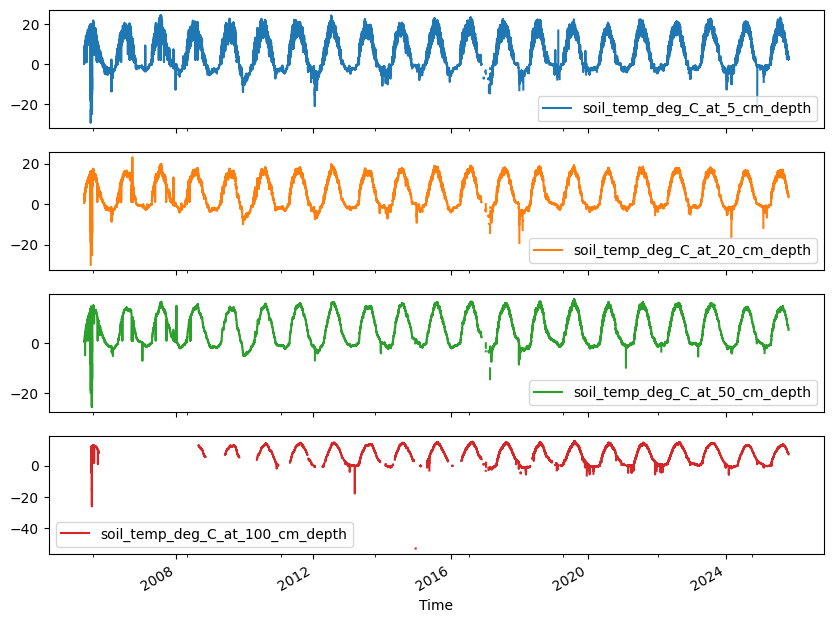

In [5]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [6]:
df_Soil_Temp_AGDM.mean()

,0
soil_temp_deg_C_at_5_cm_depth,5.766710
soil_temp_deg_C_at_20_cm_depth,5.776617
soil_temp_deg_C_at_50_cm_depth,5.827015
soil_temp_deg_C_at_100_cm_depth,7.613481


In [7]:
df_Soil_Temp_AGDM.max()

,0
soil_temp_deg_C_at_5_cm_depth,24.3
soil_temp_deg_C_at_20_cm_depth,23.1
soil_temp_deg_C_at_50_cm_depth,17.6
soil_temp_deg_C_at_100_cm_depth,15.8


In [8]:
df_Soil_Temp_AGDM.min()

,0
soil_temp_deg_C_at_5_cm_depth,-29.3
soil_temp_deg_C_at_20_cm_depth,-29.9
soil_temp_deg_C_at_50_cm_depth,-25.3
soil_temp_deg_C_at_100_cm_depth,-52.9


In [9]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_temp_deg_C_at_5_cm_depth,6504
soil_temp_deg_C_at_20_cm_depth,6013
soil_temp_deg_C_at_50_cm_depth,7328
soil_temp_deg_C_at_100_cm_depth,65928


In [10]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,173223
soil_temp_deg_C_at_20_cm_depth,173714
soil_temp_deg_C_at_50_cm_depth,172399
soil_temp_deg_C_at_100_cm_depth,113799


# Specific TH Stuck
In this method we remove any set of repeated values larger than  `sens_stuck `. This method is better for the model fitting part.

##Neighborhood Outliers

This proposal eliminates an entire neighborhood of size `segment_th` surrounding any value considered an outlier. This is because, when using the returns approach, the first point might be an outlier with respect to the previous normal trend, but subsequent points will be normal with respect to the outlier. However, only the first detected outlier will be eliminated, as subsequent returns would be normal with respect to the removed outlier.

The current method looks for outliers with a positive or negative jump and searches the surroundings for an opposite jump that adjusts to the normal value without counting intermediate NaN values ​​that might be present to remove the section completely.

###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.


In [11]:
from cleaning_stephanie import soil_temp_percentil_neighborhood_outliers

Text(0.5, 0, 'Time')

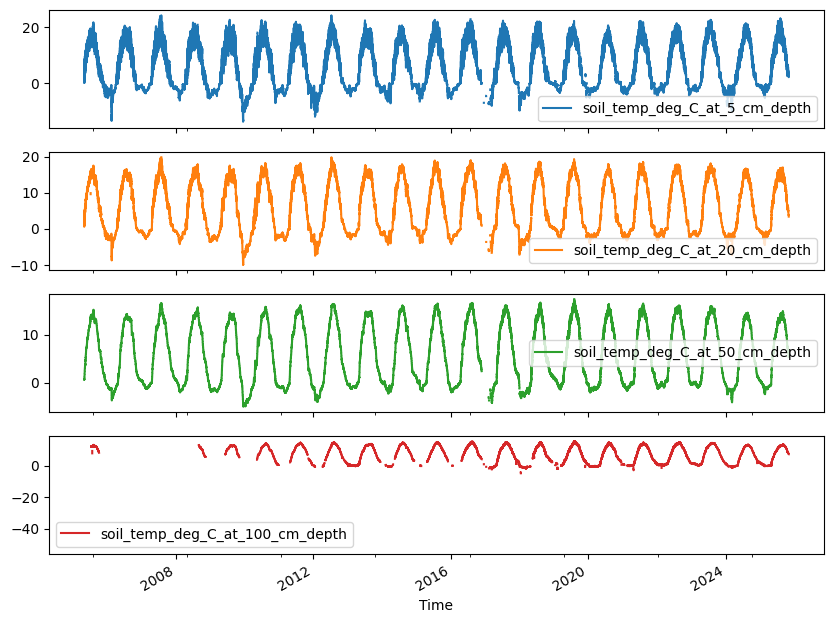

In [12]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")

In [13]:
df_Clean_per.to_csv("Rich_Lake_AGDM_temperature_cleaned.csv")

In [14]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,24.3
soil_temp_deg_C_at_20_cm_depth,19.8
soil_temp_deg_C_at_50_cm_depth,17.4
soil_temp_deg_C_at_100_cm_depth,15.7


In [15]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-14.3
soil_temp_deg_C_at_20_cm_depth,-9.9
soil_temp_deg_C_at_50_cm_depth,-5.0
soil_temp_deg_C_at_100_cm_depth,-52.8


In [16]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,166467
soil_temp_deg_C_at_20_cm_depth,166580
soil_temp_deg_C_at_50_cm_depth,164469
soil_temp_deg_C_at_100_cm_depth,108154


In [17]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,13260
soil_temp_deg_C_at_20_cm_depth,13147
soil_temp_deg_C_at_50_cm_depth,15258
soil_temp_deg_C_at_100_cm_depth,71573


In [18]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,6756
soil_temp_deg_C_at_20_cm_depth,7134
soil_temp_deg_C_at_50_cm_depth,7930
soil_temp_deg_C_at_100_cm_depth,5645


In [19]:
df_Clean_per

,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
time,,,,
2005-05-01 00:00:00,NaN,NaN,NaN,NaN
2005-05-01 01:00:00,NaN,NaN,NaN,NaN
2005-05-01 02:00:00,0.3,0.9,0.7,NaN
2005-05-01 03:00:00,0.3,0.8,0.7,NaN
2005-05-01 04:00:00,0.2,0.8,0.8,NaN
...,...,...,...,...
2025-10-31 19:00:00,2.2,3.4,5.5,7.3
2025-10-31 20:00:00,2.2,3.4,5.5,7.3
2025-10-31 21:00:00,2.3,3.4,5.4,7.3


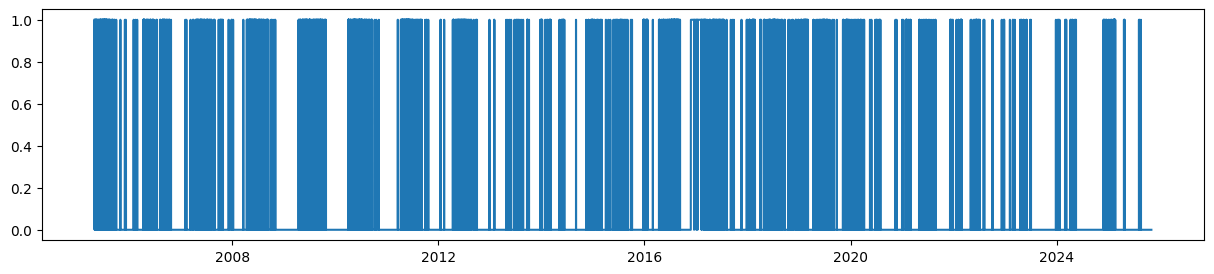

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per['soil_temp_deg_C_at_5_cm_depth'].isna())
plt.show()

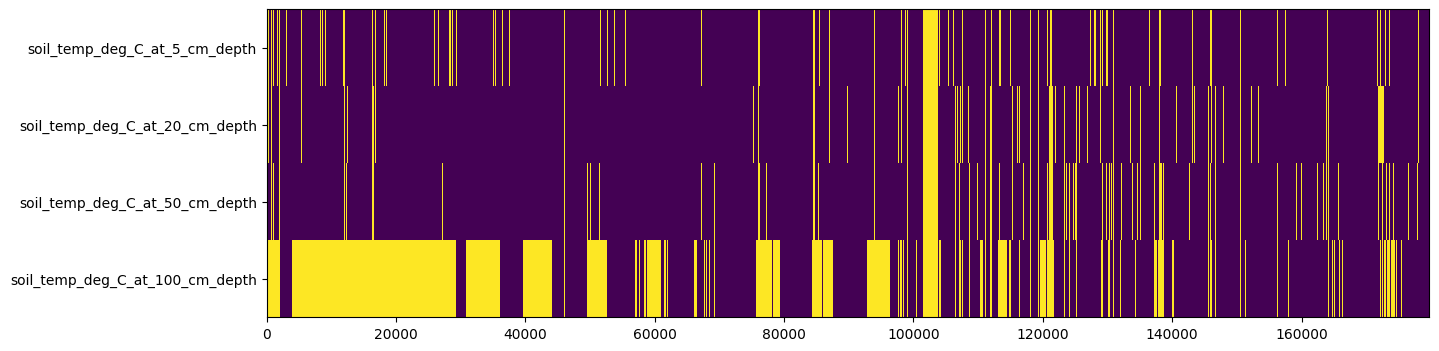

In [21]:
plt.figure(figsize=(15,4))
plt.imshow(
    df_Clean_per.isna().T,
    aspect='auto',
    interpolation='nearest'
)
plt.yticks(range(len(df_Clean_per.columns)), df_Clean_per.columns)
plt.show()

In [22]:
df_Clean_per.shape


(179727, 4)

In [23]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,13260
soil_temp_deg_C_at_20_cm_depth,13147
soil_temp_deg_C_at_50_cm_depth,15258
soil_temp_deg_C_at_100_cm_depth,71573


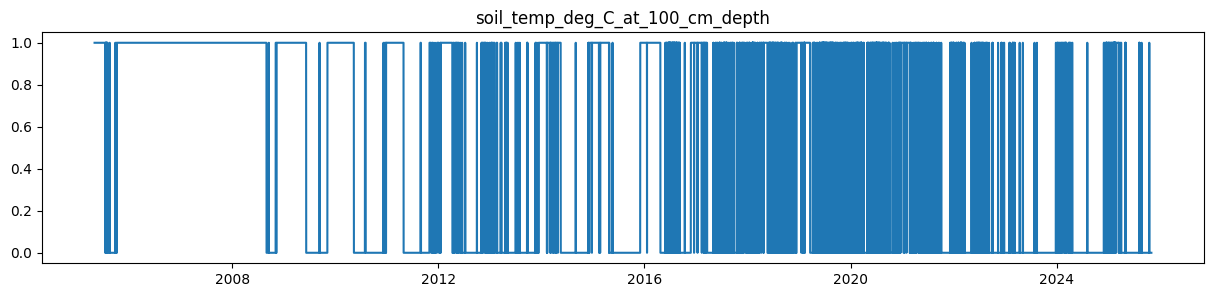

In [24]:
col = 'soil_temp_deg_C_at_100_cm_depth'

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per[col].isna().astype(int))
plt.title(col)
plt.show()

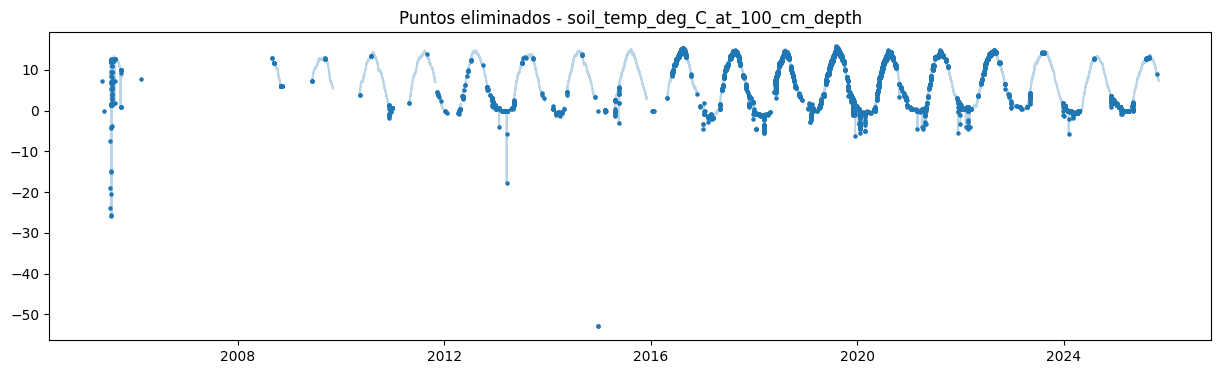

In [25]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

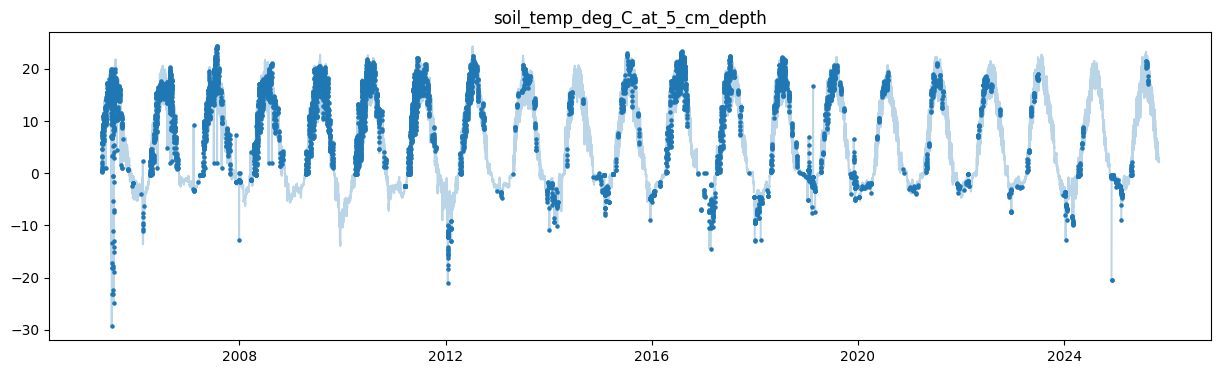

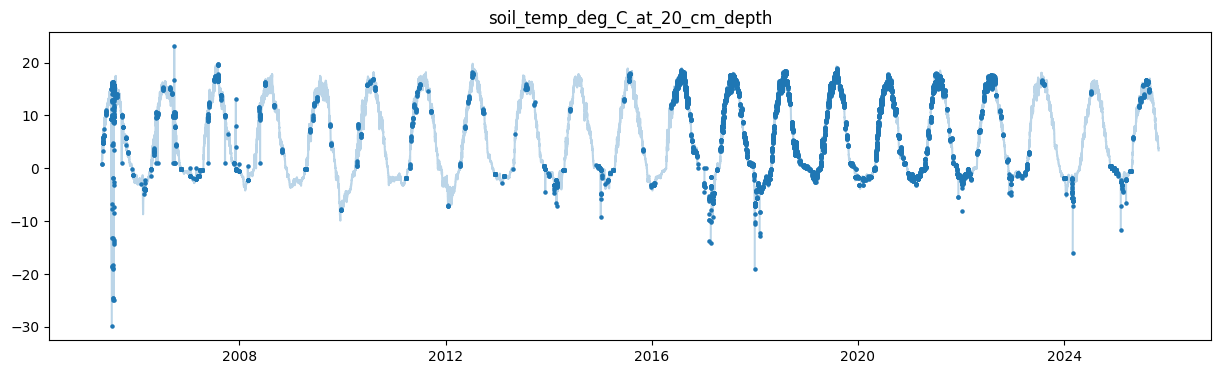

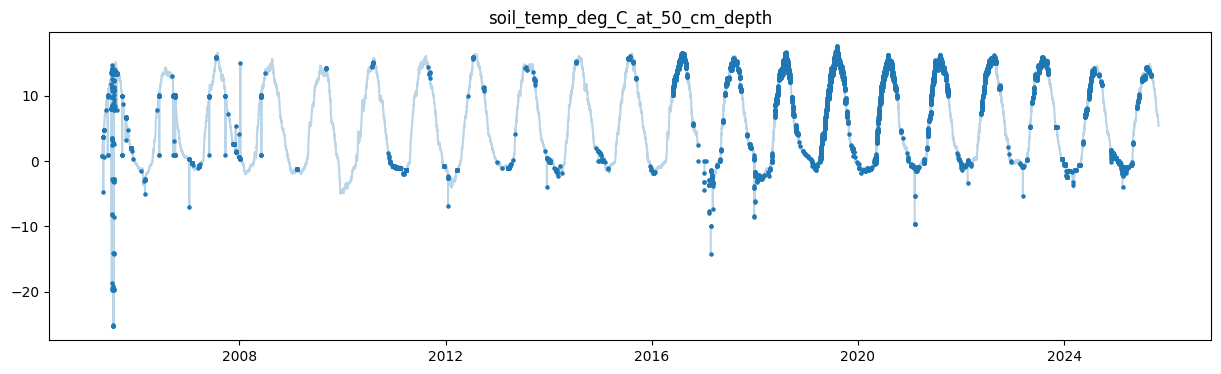

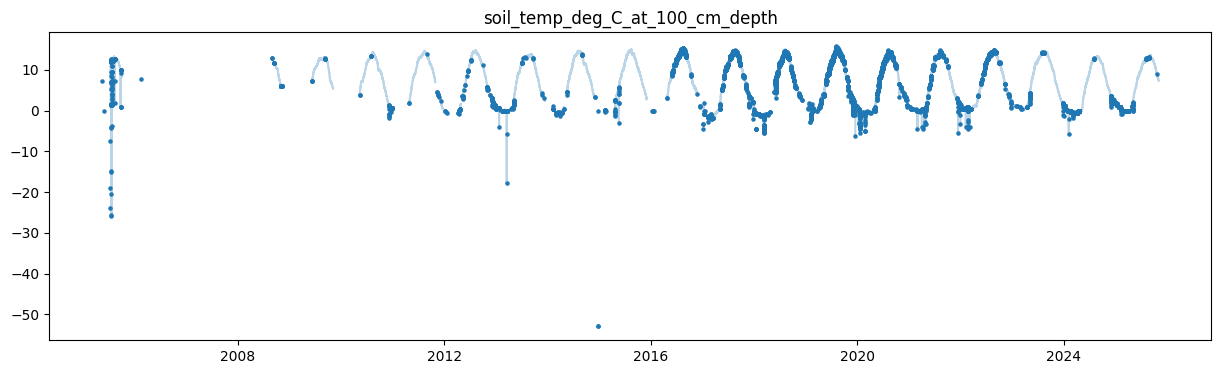

In [26]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

In [27]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,13260
soil_temp_deg_C_at_20_cm_depth,13147
soil_temp_deg_C_at_50_cm_depth,15258
soil_temp_deg_C_at_100_cm_depth,71573


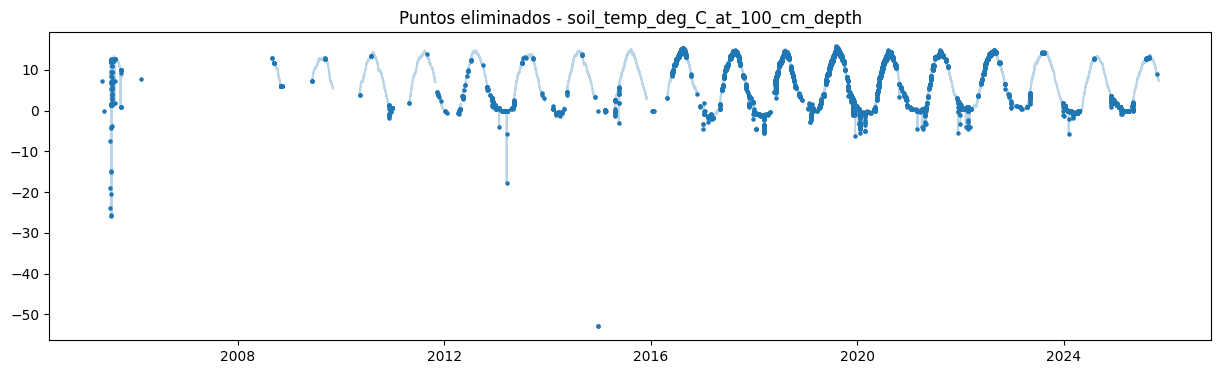

In [28]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

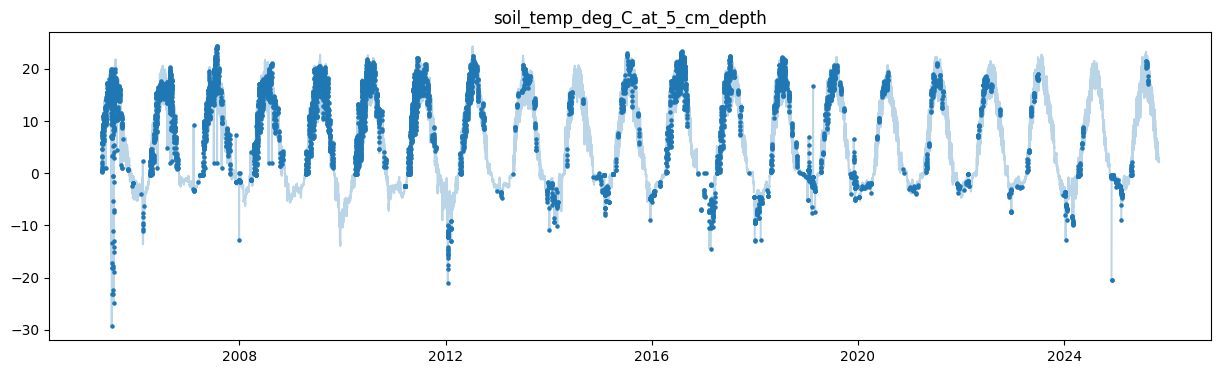

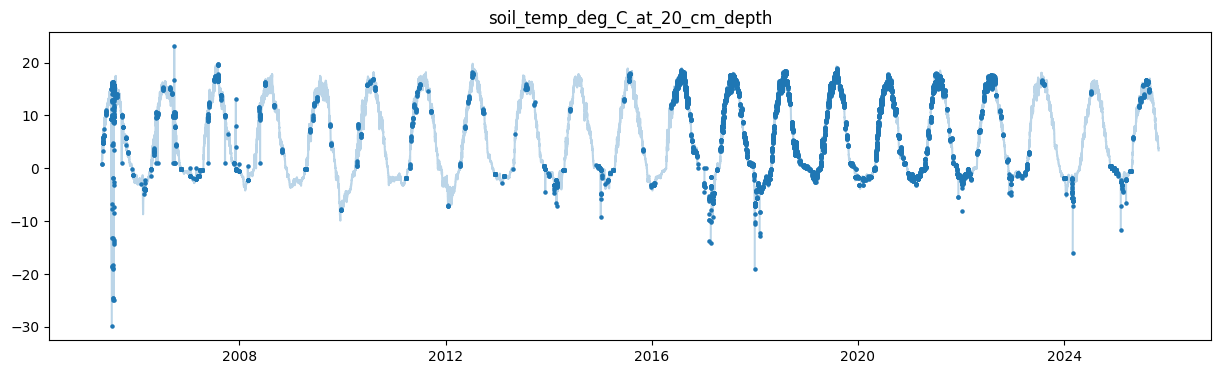

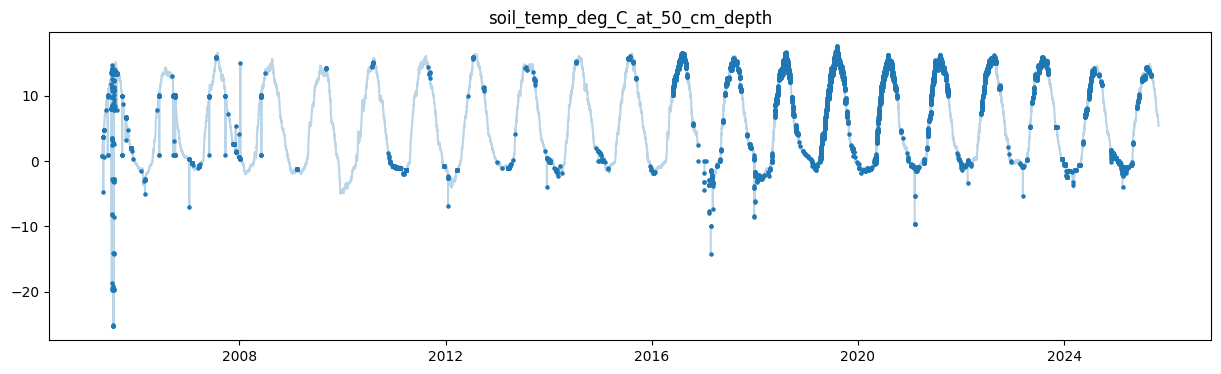

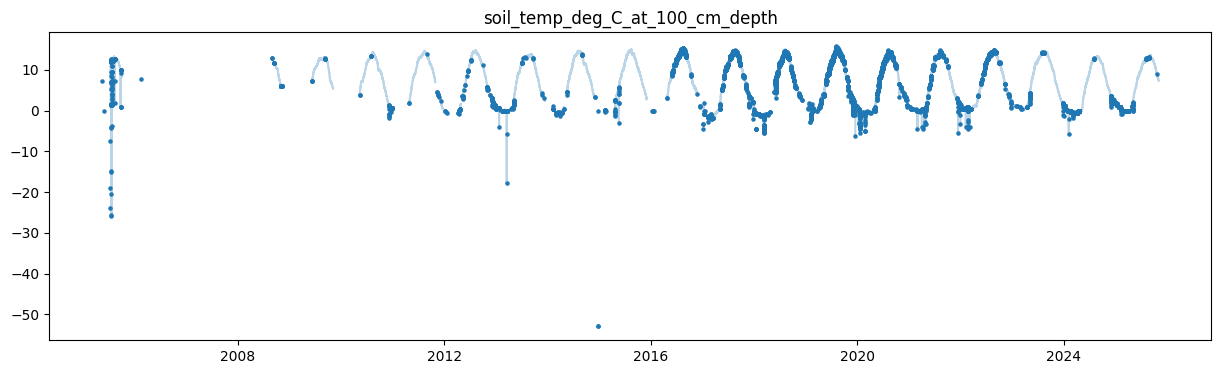

In [29]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

# Z Scores Not Used


In [30]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

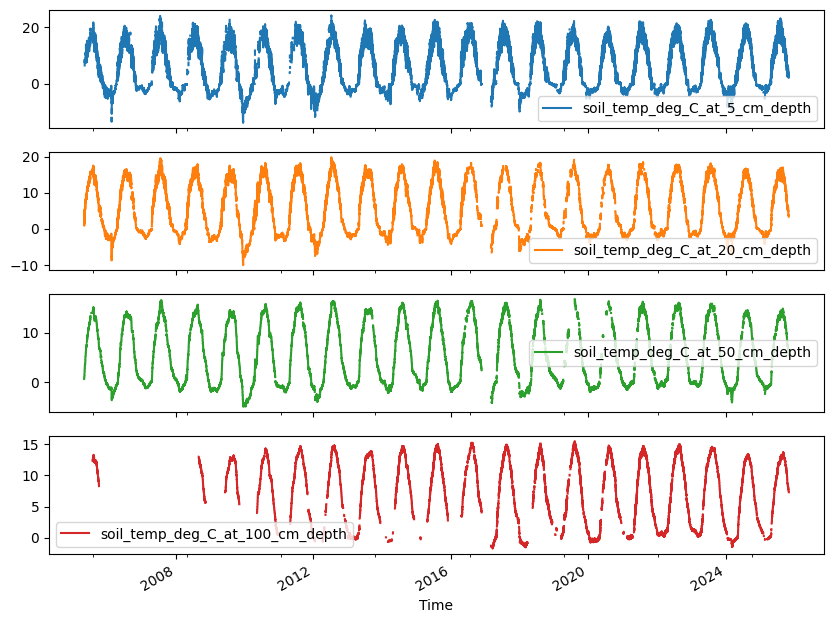

In [31]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [32]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,24.3
soil_temp_deg_C_at_20_cm_depth,19.8
soil_temp_deg_C_at_50_cm_depth,16.8
soil_temp_deg_C_at_100_cm_depth,15.5


In [33]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-13.9
soil_temp_deg_C_at_20_cm_depth,-9.9
soil_temp_deg_C_at_50_cm_depth,-5.0
soil_temp_deg_C_at_100_cm_depth,-1.7


In [34]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,129066
soil_temp_deg_C_at_20_cm_depth,134753
soil_temp_deg_C_at_50_cm_depth,129434
soil_temp_deg_C_at_100_cm_depth,83411


In [35]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,50661
soil_temp_deg_C_at_20_cm_depth,44974
soil_temp_deg_C_at_50_cm_depth,50293
soil_temp_deg_C_at_100_cm_depth,96316


In [36]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,44157
soil_temp_deg_C_at_20_cm_depth,38961
soil_temp_deg_C_at_50_cm_depth,42965
soil_temp_deg_C_at_100_cm_depth,30388


# Moisture

In [37]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Mois)
df_Soil_Temp_AGDM.head()

,time,soil_moisture_percent_at_5_cm_depth,soil_moisture_percent_at_20_cm_depth,soil_moisture_percent_at_50_cm_depth,soil_moisture_percent_at_100_cm_depth
0,2005-05-01 00:00:00,41.4,35.7,37.3,28.9
1,2005-05-01 01:00:00,41.4,35.7,37.3,28.9
2,2005-05-01 02:00:00,41.3,35.7,37.3,28.9
3,2005-05-01 03:00:00,41.3,35.7,37.3,28.9
4,2005-05-01 04:00:00,41.3,35.7,37.3,28.9


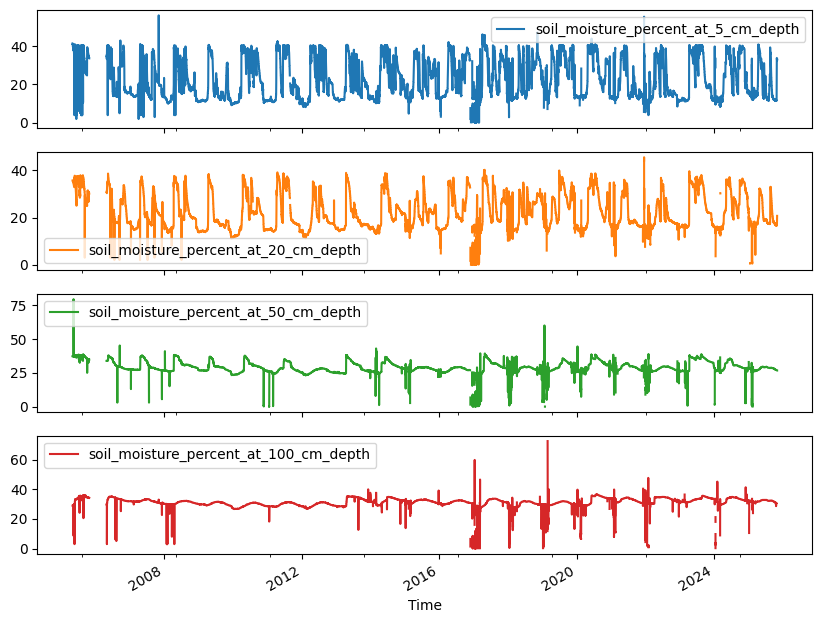

In [38]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [39]:
df_Soil_Temp_AGDM.mean()

,0
soil_moisture_percent_at_5_cm_depth,22.873767
soil_moisture_percent_at_20_cm_depth,22.416519
soil_moisture_percent_at_50_cm_depth,29.152466
soil_moisture_percent_at_100_cm_depth,31.337554


In [40]:
df_Soil_Temp_AGDM.max()

,0
soil_moisture_percent_at_5_cm_depth,56.0
soil_moisture_percent_at_20_cm_depth,45.5
soil_moisture_percent_at_50_cm_depth,79.4
soil_moisture_percent_at_100_cm_depth,72.4


In [41]:
df_Soil_Temp_AGDM.min()

,0
soil_moisture_percent_at_5_cm_depth,0.0
soil_moisture_percent_at_20_cm_depth,0.0
soil_moisture_percent_at_50_cm_depth,0.0
soil_moisture_percent_at_100_cm_depth,0.0


In [42]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_moisture_percent_at_5_cm_depth,7432
soil_moisture_percent_at_20_cm_depth,7397
soil_moisture_percent_at_50_cm_depth,8557
soil_moisture_percent_at_100_cm_depth,8558


In [43]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,172295
soil_moisture_percent_at_20_cm_depth,172330
soil_moisture_percent_at_50_cm_depth,171170
soil_moisture_percent_at_100_cm_depth,171169


###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.

Text(0.5, 0, 'Time')

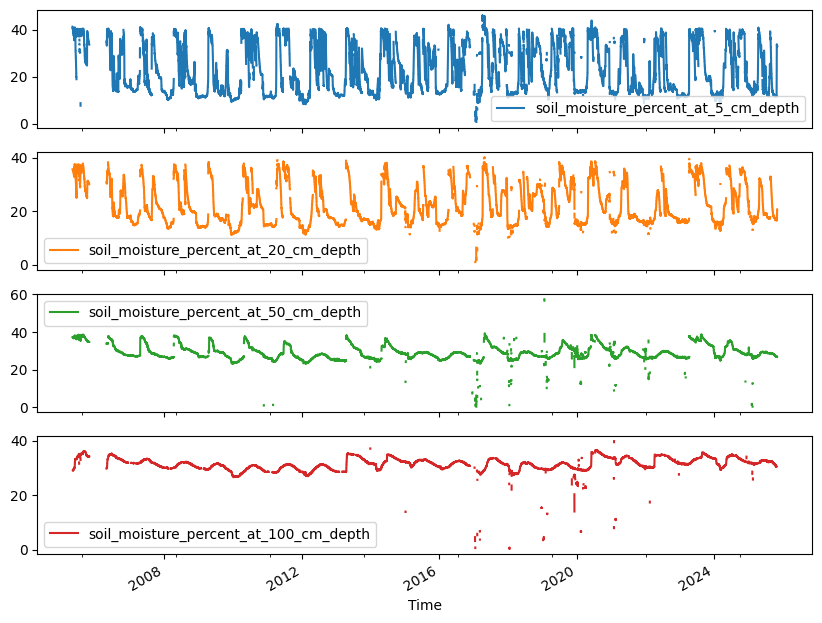

In [44]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [45]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,46.1
soil_moisture_percent_at_20_cm_depth,40.2
soil_moisture_percent_at_50_cm_depth,57.5
soil_moisture_percent_at_100_cm_depth,39.8


In [46]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,0.3
soil_moisture_percent_at_20_cm_depth,0.0
soil_moisture_percent_at_50_cm_depth,0.2
soil_moisture_percent_at_100_cm_depth,0.4


In [47]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,160733
soil_moisture_percent_at_20_cm_depth,152355
soil_moisture_percent_at_50_cm_depth,91782
soil_moisture_percent_at_100_cm_depth,49349


In [48]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,18994
soil_moisture_percent_at_20_cm_depth,27372
soil_moisture_percent_at_50_cm_depth,87945
soil_moisture_percent_at_100_cm_depth,130378


In [49]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,11562
soil_moisture_percent_at_20_cm_depth,19975
soil_moisture_percent_at_50_cm_depth,79388
soil_moisture_percent_at_100_cm_depth,121820


# Z Scores Not Used


In [50]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

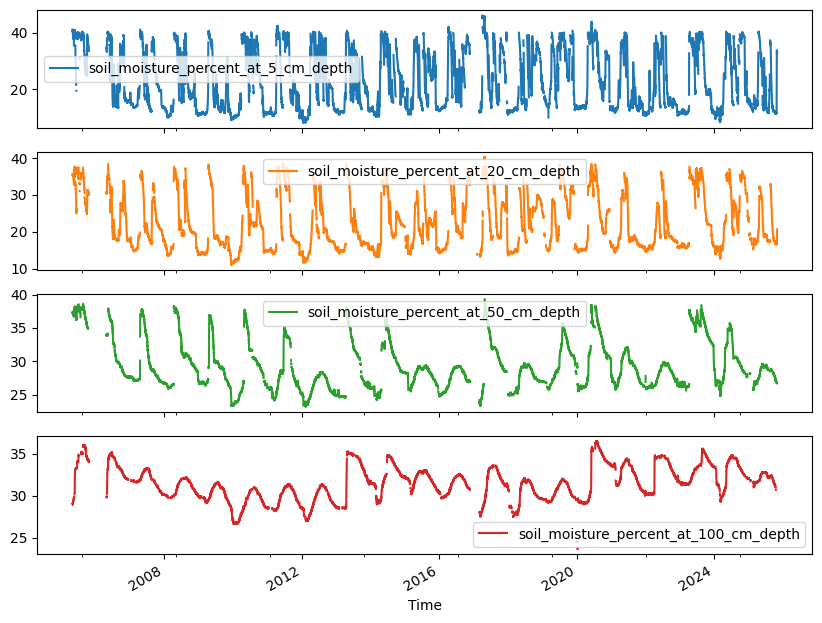

In [51]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [52]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,46.1
soil_moisture_percent_at_20_cm_depth,40.2
soil_moisture_percent_at_50_cm_depth,39.3
soil_moisture_percent_at_100_cm_depth,36.5


In [53]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,8.2
soil_moisture_percent_at_20_cm_depth,11.1
soil_moisture_percent_at_50_cm_depth,23.2
soil_moisture_percent_at_100_cm_depth,23.7


In [54]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,129714
soil_moisture_percent_at_20_cm_depth,114156
soil_moisture_percent_at_50_cm_depth,39433
soil_moisture_percent_at_100_cm_depth,27562


In [55]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,50013
soil_moisture_percent_at_20_cm_depth,65571
soil_moisture_percent_at_50_cm_depth,140294
soil_moisture_percent_at_100_cm_depth,152165


In [56]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,42581
soil_moisture_percent_at_20_cm_depth,58174
soil_moisture_percent_at_50_cm_depth,131737
soil_moisture_percent_at_100_cm_depth,143607
